In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../')))
from coco_utils import load_coco_data

# Настройка matplotlib для красивого отображения картинок
plt.rcParams['figure.figsize'] = (10.0, 8.0) # размер графиков
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Загрузка данных с уменьшенной размерностью (pca_features=True)
# max_train=5000 загрузит только небольшую часть обучающих данных для быстрой отладки.
# Когда мы будем готовы к финальному обучению, мы уберем этот параметр.
print("Загружаем данные COCO...")
data = load_coco_data(pca_features=True, max_train=5000)
print("Данные загружены.")

print("\nКлючи в загруженном словаре данных:")
for k, v in data.items():
    if isinstance(v, np.ndarray):
        print(f"- {k}: массив numpy с формой {v.shape}")
    else:
        print(f"- {k}: объект типа {type(v)}")

# Словари для перевода слов в индексы и обратно (для понимания как закодирован текст)
print(f"\nРазмер словаря (количество уникальных слов): {len(data['word_to_idx'])}")

print(f"Индекс для токена <START> -> {data['word_to_idx']['<START>']}")
print(f"Слово для индекса 1 -> {data['idx_to_word'][1]}")

Загружаем данные COCO...
base dir  D:\учеба\машинки\CNN_RNN\datasets/coco_captioning
Данные загружены.

Ключи в загруженном словаре данных:
- train_captions: массив numpy с формой (5000, 17)
- train_image_idxs: массив numpy с формой (5000,)
- val_captions: массив numpy с формой (195954, 17)
- val_image_idxs: массив numpy с формой (195954,)
- train_features: массив numpy с формой (82783, 512)
- val_features: массив numpy с формой (40504, 512)
- idx_to_word: объект типа <class 'list'>
- word_to_idx: объект типа <class 'dict'>
- train_urls: массив numpy с формой (82783,)
- val_urls: массив numpy с формой (40504,)

Размер словаря (количество уникальных слов): 1004
Индекс для токена <START> -> 1
Слово для индекса 1 -> <START>


Примеры изображений и их подписей из обучающей выборки:


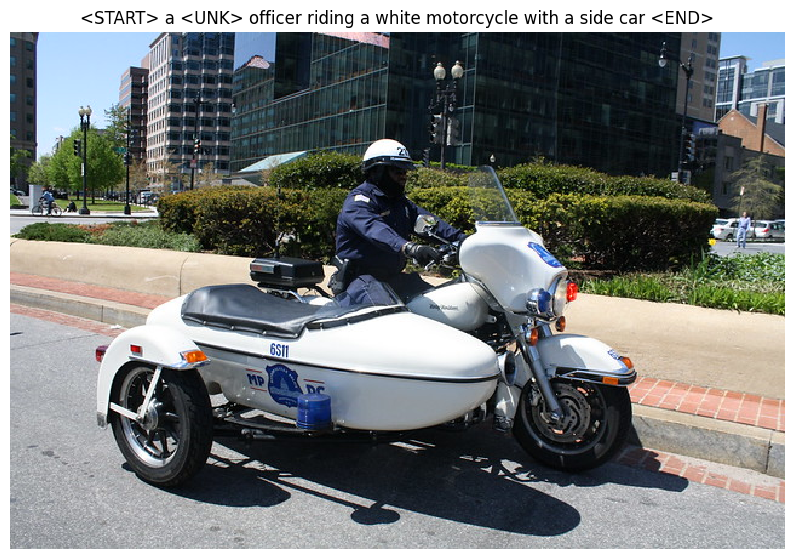

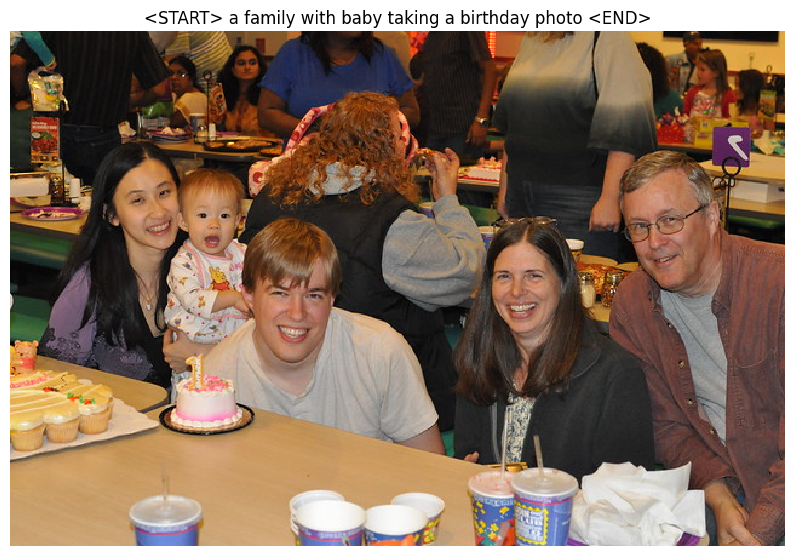

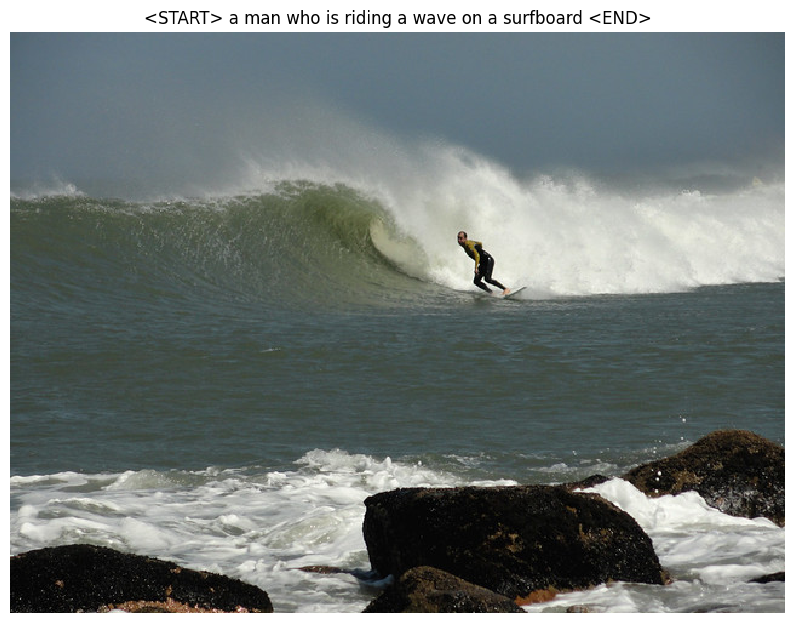

In [7]:
# Визуализация данных 
from coco_utils import sample_coco_minibatch, decode_captions
from PIL import Image
from io import BytesIO
import requests

# 2. Функция для загрузки изображения по URL
def image_from_url(url):
    """Загружает и возвращает изображение по URL."""
    try:
        response = requests.get(url)
        return Image.open(BytesIO(response.content))
    except:
        print(f"Не удалось загрузить изображение по URL: {url}")
        return Image.new('RGB', (200, 200), color = 'white')

# Получаем случайный мини-батч (небольшую порцию) данных
# Функция sample_coco_minibatch сама найдет соответствующие картинки для подписей
batch_size = 3
captions_batch, features_batch, urls_batch = sample_coco_minibatch(
    data, 
    batch_size=batch_size, 
    split='train' # из обучающей выборки
)

# Проходим по мини-батчу и выводим картинки с подписями
print("Примеры изображений и их подписей из обучающей выборки:")
for i in range(batch_size):
    url = urls_batch[i]
    caption_nums = captions_batch[i]
    caption_text = decode_captions(caption_nums, data['idx_to_word'])
    img = image_from_url(url)
    plt.imshow(img)
    plt.axis('off') 
    plt.title(caption_text)
    plt.show()

In [ ]:
# Определение архитектуры RNN-декодера
import torch
import torch.nn as nn

# Паараметры для будущей модели
WORD_VEC_SIZE = 256  # Размер вектора для каждого слова
HIDDEN_SIZE = 512   # Размер скрытого состояния в RNN
IMG_FEAT_SIZE = 512  # Размер вектора признаков изображения (из PCA-версии)
VOCAB_SIZE = len(data['word_to_idx']) # Размер нашего словаря (1004)

class CaptioningRNN(nn.Module):
    """
    Класс для нашей модели Image Captioning.
    Архитектура: (a) Init-inject
    """
    def __init__(self, word_vec_size, hidden_size, vocab_size, img_feat_size):
        super().__init__()
        
        # Слой для признаков изображения (Image features layer)
        # Преобразует вектор признаков картинки в нужный размер для скрытого состояния RNN.
        # Вход: IMG_FEAT_SIZE (512), Выход: HIDDEN_SIZE (512)
        self.img_to_hidden = nn.Linear(img_feat_size, hidden_size)

        # Слой для встраивания слов (Word embedding layer)
        # Преобразует индекс слова (например, 56) в плотный вектор (размером WORD_VEC_SIZE).
        # Это как бы смысловой вектор для каждого слова.
        self.word_embedding = nn.Embedding(vocab_size, word_vec_size)

        # Рекуррентный слой (LSTM)
        # Основной движок модели, который обрабатывает последовательность слов.
        # Вход: вектор слова, Выход: новое скрытое состояние
        self.lstm = nn.LSTM(word_vec_size, hidden_size)

        # Выходной слой (Output layer)
        # Преобразует скрытое состояние RNN в "оценки" (логиты) для каждого слова в словаре.
        # Вход: HIDDEN_SIZE (512), Выход: VOCAB_SIZE (1004)
        self.hidden_to_vocab = nn.Linear(hidden_size, vocab_size)

    def forward(self, features, captions):
        """
        Прямой проход для обучения модели.
        features: признаки изображений, форма (N, D_img)
        captions: подписи, форма (N, T)
        """
        captions_in = captions[:, :-1]
        
        # Получаем встраивания (embeddings) для входных слов (N, T-1) -> (N, T-1, D_word)
        word_embeds = self.word_embedding(captions_in)
        
        # Транспонируем, так как RNN в PyTorch ожидает (T, N, D_word)
        word_embeds = word_embeds.transpose(0, 1)

        # Используем признаки изображения для инициализации скрытого состояния LSTM (N, D_img) -> (N, D_hidden)
        initial_hidden = self.img_to_hidden(features)
        
        # LSTM требует скрытое состояние в виде кортежа (h0, c0)
        # Мы будем использовать один и тот же вектор для обоих
        # Форма должна быть (1, N, D_hidden)
        h0 = initial_hidden.unsqueeze(0)
        c0 = initial_hidden.unsqueeze(0)

        # Прогоняем последовательность через LSTM
        # lstm_out будет иметь форму (T-1, N, D_hidden)
        lstm_out, _ = self.lstm(word_embeds, (h0, c0))
        
        # Получаем оценки для каждого слова в словаре
        # (T-1, N, D_hidden) -> (T-1, N, V)
        vocab_scores = self.hidden_to_vocab(lstm_out)

        # Транспонируем обратно в (N, T-1, V) для удобства подсчета потерь
        vocab_scores = vocab_scores.transpose(0, 1)
        
        return vocab_scores

rnn_model = CaptioningRNN(
    word_vec_size=WORD_VEC_SIZE,
    hidden_size=HIDDEN_SIZE,
    vocab_size=VOCAB_SIZE,
    img_feat_size=IMG_FEAT_SIZE
)

print("Класс модели CaptioningRNN успешно определен.")
print("Экземпляр модели создан.")

Класс модели CaptioningRNN успешно определен.
Экземпляр модели создан.


In [ ]:
# Определение функции потерь и оптимизатора

device = torch.device('cpu')
rnn_model.to(device)

# Определяем функцию потерь
# Используется **nn.CrossEntropyLoss**, так как предсказание следующего слова 
# является задачей многоклассовой классификации на размер словаря.
# 
# Критически важен параметр ignore_index='<NULL>'
# Он предназначен для маскирования потерь по токенам-заполнителям, которые используются 
# для выравнивания батчей. Это гарантирует, что модель не тратит вычислительные
# ресурсы и не обучается предсказывать служебные токены `<NULL>`.
loss_fn = nn.CrossEntropyLoss(ignore_index=data['word_to_idx']['<NULL>'])

# Определяем оптимизатор
# Adam - это надежный выбор по умолчанию для большинства задач глубокого обучения.
# rnn_model.parameters() передает оптимизатору все обучаемые параметры нашей модели.
learning_rate = 1e-3 
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=learning_rate)

# Определяем планировщик скорости обучения (Learning Rate Scheduler)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',      # Мы следим за минимизацией потерь
    factor=0.1,      # Уменьшаем lr в 10 раз 
    patience=5      # Ждем 5 эпох без улучшений, прежде чем уменьшить
)

print("\nФункция потерь, оптимизатор и планировщик успешно определены.")


Функция потерь, оптимизатор и планировщик успешно определены.


In [28]:
# Цикл обучения
from torch.utils.data import TensorDataset, DataLoader

# Подготовка данных для загрузчика (DataLoader)

# Создаем TensorDataset для обучающей выборки. Он "связывает" подписи с индексами соответствующих картинок.
train_dataset = TensorDataset(
    torch.from_numpy(data['train_captions']).long(),
    torch.from_numpy(data['train_image_idxs'])
)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

val_dataset = TensorDataset(
    torch.from_numpy(data['val_captions']).long(),
    torch.from_numpy(data['val_image_idxs'])
)
val_loader = DataLoader(val_dataset, batch_size=128)


num_epochs = 3 

print("Начинаем обучение...")
for epoch in range(num_epochs):
    
    # Фаза обучения (Training)
    rnn_model.train()
    total_train_loss = 0.0
    
    for captions, img_idxs in train_loader:
        captions = captions.to(device).long()
        img_idxs = img_idxs.to(device)
        
        features = torch.from_numpy(data['train_features'][img_idxs.cpu()]).to(device)
        
        optimizer.zero_grad()
        
        # Получаем предсказания модели (прямой проход)
        # Выход `scores` будет иметь форму (N, T-1, V)
        scores = rnn_model(features, captions)
        
        # Считаем ошибку
        # Нам нужно сравнить предсказания `scores` с целевыми подписями `captions`.
        # Целевые подписи - это входные, но сдвинутые на один шаг вперед (без <START>).
        captions_target = captions[:, 1:]
        
        # `CrossEntropyLoss` ожидает на вход `scores` в форме (N * (T-1), V) и
        # `captions_target` в форме (N * (T-1)). "Вытягиваем" наши тензоры.
        loss = loss_fn(scores.reshape(-1, VOCAB_SIZE), captions_target.reshape(-1))
        
        # Обратный проход
        loss.backward()

        # Обновляем веса модели
        optimizer.step()
        
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    
    # Фаза валидации (Validation)
    rnn_model.eval() 
    total_val_loss = 0.0
    
    with torch.no_grad(): 
        for captions, img_idxs in val_loader:
            captions = captions.to(device).long()
            img_idxs = img_idxs.to(device)
            features = torch.from_numpy(data['val_features'][img_idxs.cpu()]).to(device)
            
            scores = rnn_model(features, captions)
            captions_target = captions[:, 1:]
            
            loss = loss_fn(scores.reshape(-1, VOCAB_SIZE), captions_target.reshape(-1))
            total_val_loss += loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    
    print(f"Эпоха {epoch + 1}/{num_epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}")
    
    scheduler.step(avg_val_loss)

print("\nОбучение завершено.")

Начинаем обучение...
Эпоха 1/3 | Train Loss: 4.8853 | Val Loss: 4.0253
Эпоха 2/3 | Train Loss: 3.7189 | Val Loss: 3.5558
Эпоха 3/3 | Train Loss: 3.2561 | Val Loss: 3.2851

Обучение завершено.


In [29]:
# Функция для генерации подписей

def sample(model, features, max_len=16):
    """
    Генерирует подпись для изображения в режиме предсказания (inference).
    
    Inputs:
    - model: Обученная модель CaptioningRNN.
    - features: Вектор признаков для одного изображения, форма (D_img,).
    - max_len: Максимальная длина генерируемой подписи.

    Returns:
    - caption: Массив numpy с индексами слов сгенерированной подписи.
    """
    
    model.eval() # Переключаем модель в режим оценки
    caption = []
    
    # Готовим входы для LSTM. Он ожидает (1, 1, D_input)
    # Начинаем с токена <START>
    start_token_idx = data['word_to_idx']['<START>']
    word_idx = torch.tensor(start_token_idx).view(1, 1).to(device).long()
    
    with torch.no_grad(): 
        initial_hidden = model.img_to_hidden(features.to(device).unsqueeze(0))
        h = initial_hidden.unsqueeze(0)
        c = initial_hidden.unsqueeze(0)
        
        caption.append(start_token_idx)

        # Пошаговая генерация
        for _ in range(max_len):
            # Получаем встраивание (embedding) для текущего слова
            word_embed = model.word_embedding(word_idx)
            
            # Прогоняем один шаг через LSTM
            lstm_out, (h, c) = model.lstm(word_embed, (h, c))
            
            # Получаем оценки для следующего слова
            scores = model.hidden_to_vocab(lstm_out.squeeze(0))
            
            # Выбираем слово с максимальной оценкой (самое вероятное)
            _, next_word_idx = scores.max(1)
            
            # Добавляем предсказанное слово в нашу подпись
            caption.append(next_word_idx.item())
            
            # Если модель предсказала <END>, останавливаем генерацию
            if next_word_idx.item() == data['word_to_idx']['<END>']:
                break
                
            # Следующим входом для LSTM будет только что предсказанное слово
            word_idx = next_word_idx.unsqueeze(0)
            
    return np.array(caption)

print("Функция sample для генерации подписей определена.")

Функция sample для генерации подписей определена.


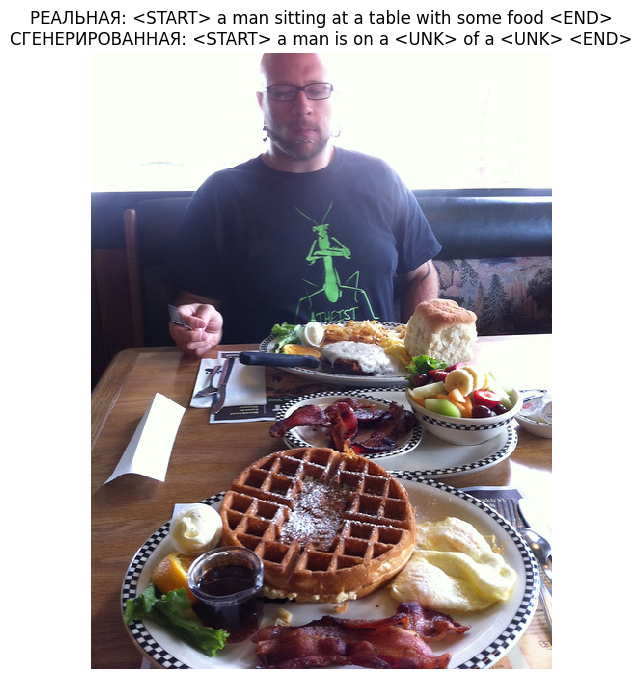

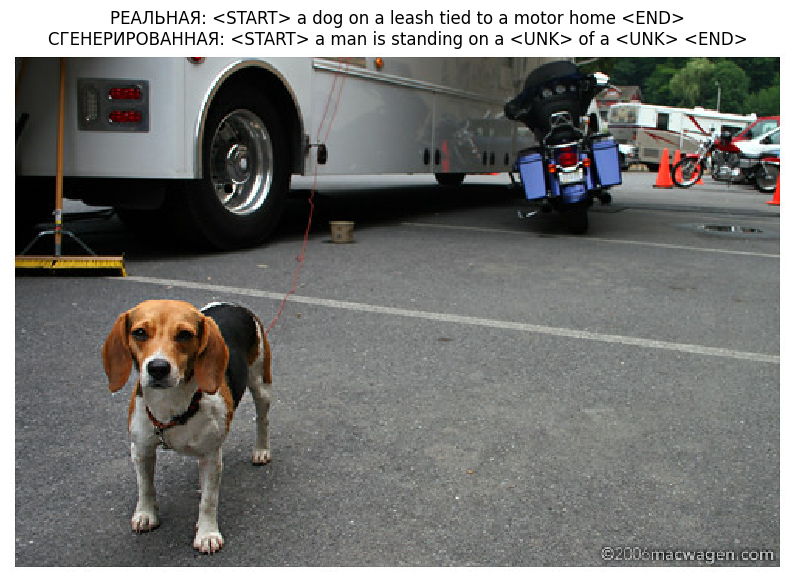

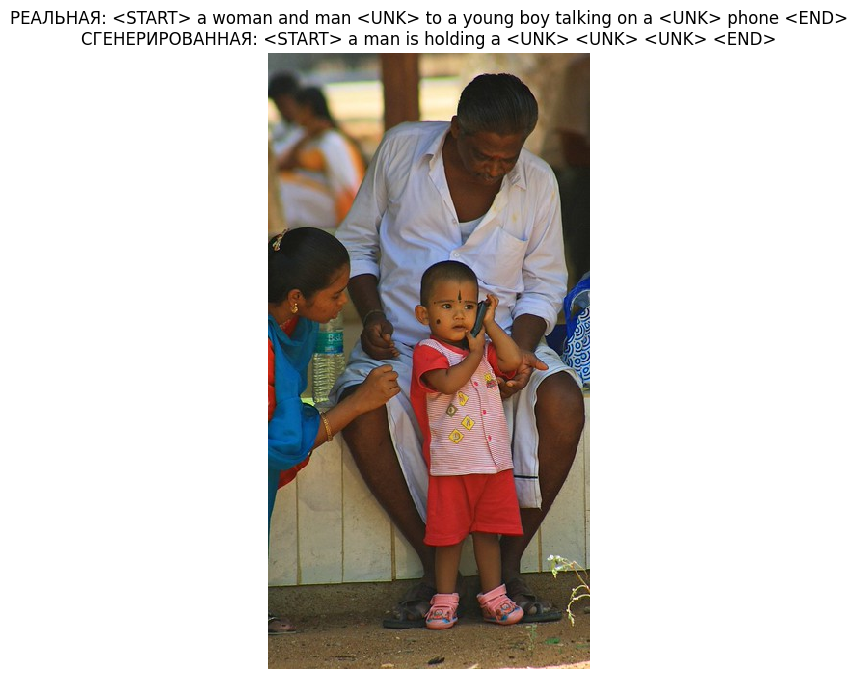

In [30]:
# Тестирование генерации подписей 
num_samples = 3

for i in range(num_samples):
    # Берем случайный пример из валидационных данных
    # np.random.choice, чтобы каждый раз были разные картинки
    idx = np.random.choice(len(data['val_captions']))
    
    caption_nums = data['val_captions'][idx]
    url = data['val_urls'][data['val_image_idxs'][idx]]
    
    # Получаем признаки изображения
    features_single = torch.from_numpy(data['val_features'][data['val_image_idxs'][idx]])

    generated_caption_nums = sample(rnn_model, features_single)
    
    # Декодируем обе подписи (реальную и сгенерированную) в текст
    real_caption_text = decode_captions(caption_nums, data['idx_to_word'])
    generated_caption_text = decode_captions(generated_caption_nums, data['idx_to_word'])
    
    img = image_from_url(url)
    plt.imshow(img)
    plt.axis('off')
    
    plt.title(f"РЕАЛЬНАЯ: {real_caption_text}\nСГЕНЕРИРОВАННАЯ: {generated_caption_text}")
    plt.show()

In [31]:
# Финальное обучение

import torch
device = torch.device('cpu')
print("Используем CPU.")

print("\nЗагружаем ПОЛНЫЙ набор данных COCO...")
full_data = load_coco_data(pca_features=True)
print("Данные загружены.")

IMG_FEAT_SIZE = full_data['train_features'].shape[1]
VOCAB_SIZE = len(full_data['word_to_idx'])

# Создание новой "чистой" модели для финального обучения
final_model = CaptioningRNN(
    word_vec_size=WORD_VEC_SIZE,
    hidden_size=HIDDEN_SIZE,
    vocab_size=VOCAB_SIZE,
    img_feat_size=IMG_FEAT_SIZE
).to(device)

loss_fn_final = nn.CrossEntropyLoss(ignore_index=full_data['word_to_idx']['<NULL>'])
optimizer_final = torch.optim.Adam(final_model.parameters(), lr=1e-3)
scheduler_final = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_final, mode='min', factor=0.1, patience=3, verbose=True 
)

train_dataset_final = TensorDataset(
    torch.from_numpy(full_data['train_captions']).long(),
    torch.from_numpy(full_data['train_image_idxs'])
)
train_loader_final = DataLoader(train_dataset_final, batch_size=256, shuffle=True)

val_dataset_final = TensorDataset(
    torch.from_numpy(full_data['val_captions']).long(),
    torch.from_numpy(full_data['val_image_idxs'])
)
val_loader_final = DataLoader(val_dataset_final, batch_size=256)

num_epochs_final = 4

print(f"\nНачинаем финальное обучение на {num_epochs_final} эпох...")
for epoch in range(num_epochs_final):
    final_model.train()
    total_train_loss = 0.0
    for captions, img_idxs in train_loader_final:
        captions = captions.to(device)
        img_idxs = img_idxs.to(device)
        features = torch.from_numpy(full_data['train_features'][img_idxs.cpu()]).to(device)
        optimizer_final.zero_grad()
        scores = final_model(features, captions)
        captions_target = captions[:, 1:]
        loss = loss_fn_final(scores.reshape(-1, VOCAB_SIZE), captions_target.reshape(-1))
        loss.backward()
        optimizer_final.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader_final)
    
    final_model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for captions, img_idxs in val_loader_final:
            captions = captions.to(device)
            img_idxs = img_idxs.to(device)
            features = torch.from_numpy(full_data['val_features'][img_idxs.cpu()]).to(device)
            scores = final_model(features, captions)
            captions_target = captions[:, 1:]
            loss = loss_fn_final(scores.reshape(-1, VOCAB_SIZE), captions_target.reshape(-1))
            total_val_loss += loss.item()
    avg_val_loss = total_val_loss / len(val_loader_final)
    
    print(f"Эпоха {epoch + 1}/{num_epochs_final} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}")
    
    scheduler_final.step(avg_val_loss)

print("\nОбучение завершено.")

torch.save(final_model.state_dict(), 'init_inject_final_model.pth')
print("Веса модели сохранены в файл 'init_inject_final_model.pth'")

Используем CPU.

Загружаем ПОЛНЫЙ набор данных COCO...
base dir  D:\учеба\машинки\CNN_RNN\datasets/coco_captioning
Данные загружены.

Начинаем финальное обучение на 4 эпох...
Эпоха 1/4 | Train Loss: 2.5399 | Val Loss: 2.2932
Эпоха 2/4 | Train Loss: 2.1783 | Val Loss: 2.2287
Эпоха 3/4 | Train Loss: 2.0884 | Val Loss: 2.2107
Эпоха 4/4 | Train Loss: 2.0298 | Val Loss: 2.2092

Обучение завершено.
Веса модели сохранены в файл 'init_inject_final_model.pth'


Генерируем подписи с помощью финальной, обученной модели:


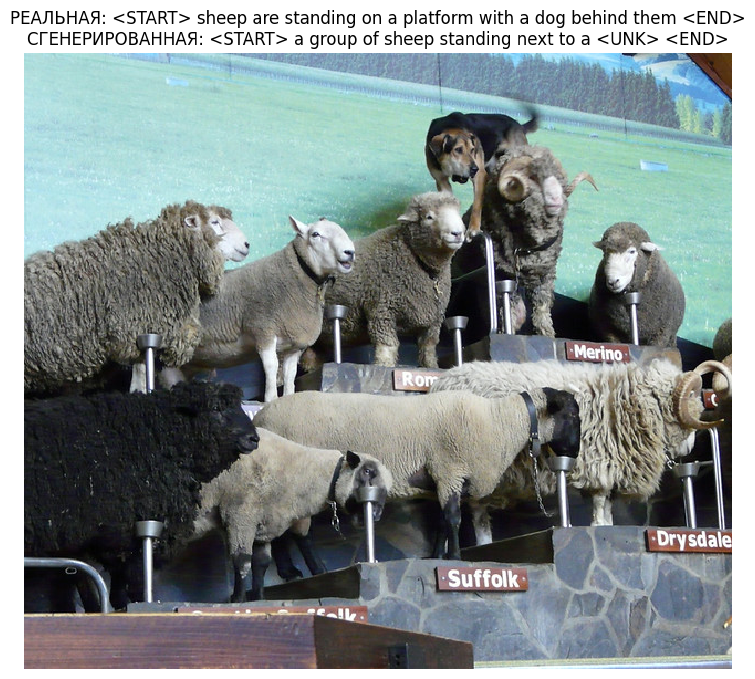

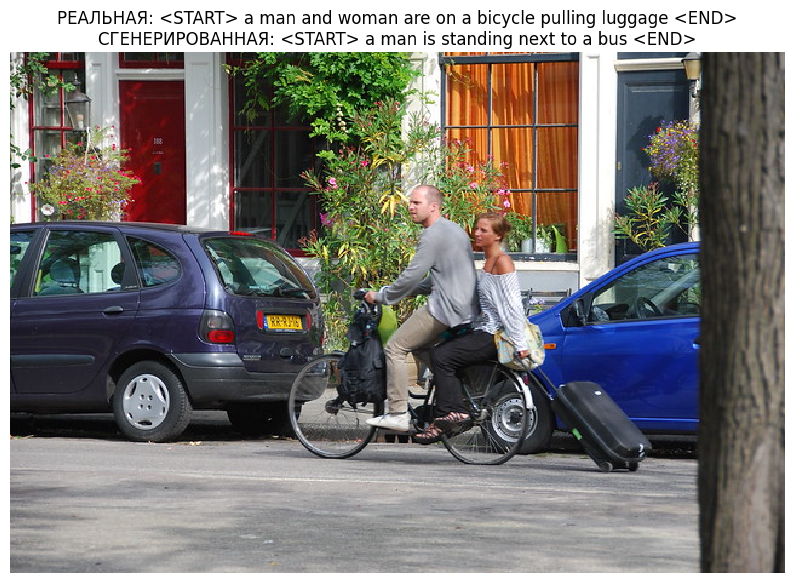

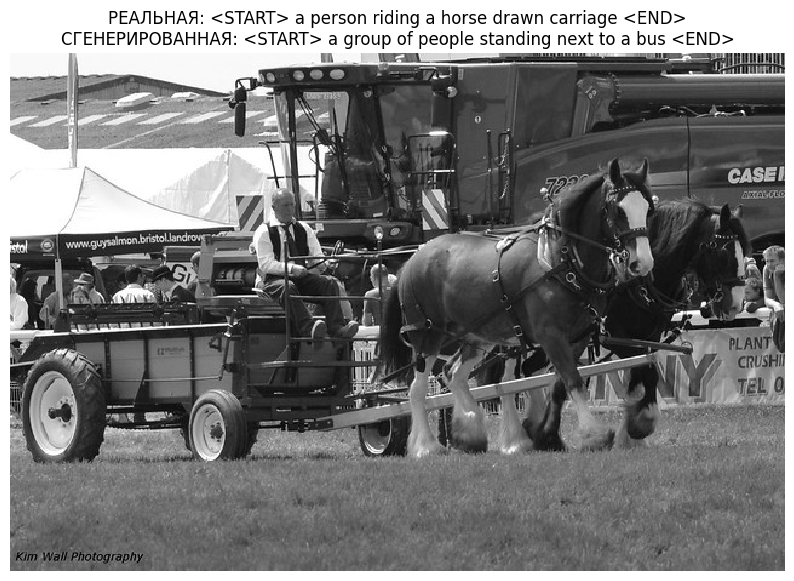

In [37]:
# Тестирование Финальной модели ---

# Загружать модель с диска не нужно, так как она уже есть в памяти
# в переменной `final_model`
# 
# Но если бы мы перезапускали ноутбук: final_model.load_state_dict(torch.load('init_inject_final_model.pth'))

num_samples = 3

print("Генерируем подписи с помощью финальной, обученной модели:")
for i in range(num_samples):
    idx = np.random.choice(len(full_data['val_captions']))
    
    caption_nums = full_data['val_captions'][idx]
    url = full_data['val_urls'][full_data['val_image_idxs'][idx]]
    
    features_single = torch.from_numpy(full_data['val_features'][full_data['val_image_idxs'][idx]])
    generated_caption_nums = sample(final_model, features_single)
    real_caption_text = decode_captions(caption_nums, full_data['idx_to_word'])
    generated_caption_text = decode_captions(generated_caption_nums, full_data['idx_to_word'])
    
    img = image_from_url(url)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"РЕАЛЬНАЯ: {real_caption_text}\nСГЕНЕРИРОВАННАЯ: {generated_caption_text}")
    plt.show()

In [38]:
# Определение второй архитектуры: (b) Pre-inject 

class CaptioningRNN_PreInject(nn.Module):
    def __init__(self, word_vec_size, hidden_size, vocab_size, img_feat_size):
        super().__init__()
        
        # Слои модели 
        
        # Преобразуем вектор картинки в тот же размер, что и вектор слова
        # Чтобы их можно было подавать в LSTM как часть одной последовательности.
        # Вход: IMG_FEAT_SIZE (512), Выход: WORD_VEC_SIZE (256)
        self.img_to_word_vec = nn.Linear(img_feat_size, word_vec_size)
        
        self.word_embedding = nn.Embedding(vocab_size, word_vec_size)
        self.lstm = nn.LSTM(word_vec_size, hidden_size)
        self.hidden_to_vocab = nn.Linear(hidden_size, vocab_size)

    def forward(self, features, captions):
        # Убираем токен <END>
        captions_in = captions[:, :-1]
        
        # Получаем встраивания (embeddings) для слов
        # (N, T-1) -> (N, T-1, D_word)
        word_embeds = self.word_embedding(captions_in)
        
        # Преобразуем признаки изображения в "псевдо-вектор слова"
        # (N, D_img) -> (N, D_word)
        img_embeds = self.img_to_word_vec(features)
        
        # Добавляем измерение времени: (N, D_word) -> (N, 1, D_word)
        img_embeds = img_embeds.unsqueeze(1)
        
        # Объединяем вектор картинки и векторы слов в одну последовательность
        # (N, 1, D_word) + (N, T-1, D_word) -> (N, T, D_word)
        full_sequence = torch.cat([img_embeds, word_embeds], dim=1)
        
        # Транспонируем для LSTM: (T, N, D_word)
        full_sequence = full_sequence.transpose(0, 1)

        # Прогоняем ПОЛНУЮ последовательность через LSTM.
        lstm_out, _ = self.lstm(full_sequence)
        
        # Получаем оценки для каждого слова в словаре
        # (T, N, D_hidden) -> (T, N, V)
        vocab_scores = self.hidden_to_vocab(lstm_out)

        # Транспонируем обратно в (N, T, V)
        vocab_scores = vocab_scores.transpose(0, 1)
        
        return vocab_scores[:, :-1, :]

preinject_model = CaptioningRNN_PreInject(
    word_vec_size=WORD_VEC_SIZE,
    hidden_size=HIDDEN_SIZE,
    vocab_size=VOCAB_SIZE,
    img_feat_size=IMG_FEAT_SIZE
)

print("Класс второй модели CaptioningRNN_PreInject успешно определен.")
print("Экземпляр модели создан.")

Класс второй модели CaptioningRNN_PreInject успешно определен.
Экземпляр модели создан.


In [39]:
# Обучение второй архитектуры (Pre-inject)

preinject_model.to(device)

optimizer_preinject = torch.optim.Adam(preinject_model.parameters(), lr=1e-3)
scheduler_preinject = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_preinject, mode='min', factor=0.1, patience=3, verbose=True
)

num_epochs_preinject = 4 

print(f"\nНачинаем обучение второй модели (Pre-inject) на {num_epochs_preinject} эпох...")
for epoch in range(num_epochs_preinject):
    
    # Фаза обучения
    preinject_model.train()
    total_train_loss = 0.0
    for captions, img_idxs in train_loader_final:
        captions = captions.to(device)
        img_idxs = img_idxs.cpu()
        features = torch.from_numpy(full_data['train_features'][img_idxs]).to(device)
        
        optimizer_preinject.zero_grad()
        scores = preinject_model(features, captions)
        captions_target = captions[:, 1:]
        
        loss = loss_fn_final(scores.reshape(-1, VOCAB_SIZE), captions_target.reshape(-1))
        loss.backward()
        optimizer_preinject.step()
        
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader_final)
    
    # Фаза валидации
    preinject_model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for captions, img_idxs in val_loader_final:
            captions = captions.to(device)
            img_idxs = img_idxs.cpu()
            features = torch.from_numpy(full_data['val_features'][img_idxs]).to(device)
            
            scores = preinject_model(features, captions)
            captions_target = captions[:, 1:]
            
            loss = loss_fn_final(scores.reshape(-1, VOCAB_SIZE), captions_target.reshape(-1))
            total_val_loss += loss.item()
    avg_val_loss = total_val_loss / len(val_loader_final)
    
    print(f"Эпоха {epoch + 1}/{num_epochs_preinject} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f}")
    
    scheduler_preinject.step(avg_val_loss)

print("\nОбучение второй модели завершено.")

torch.save(preinject_model.state_dict(), 'preinject_final_model.pth')
print("Веса второй модели сохранены в файл 'preinject_final_model.pth'")


Начинаем обучение второй модели (Pre-inject) на 4 эпох...
Эпоха 1/4 | Train Loss: 3.2747 | Val Loss: 3.0363
Эпоха 2/4 | Train Loss: 2.9258 | Val Loss: 2.9589
Эпоха 3/4 | Train Loss: 2.8314 | Val Loss: 2.9319
Эпоха 4/4 | Train Loss: 2.7673 | Val Loss: 2.9257

Обучение второй модели завершено.
Веса второй модели сохранены в файл 'preinject_final_model.pth'


Генерируем подписи с помощью второй модели (Pre-inject):


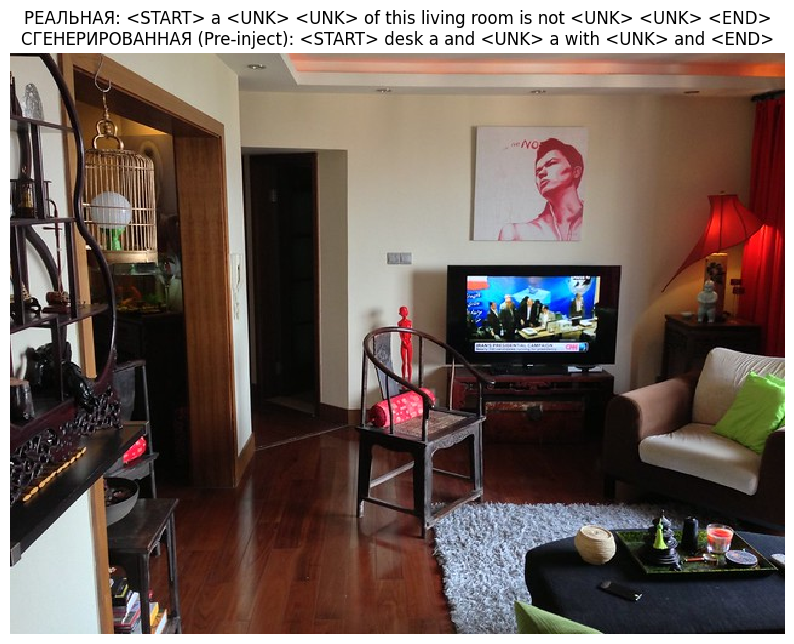

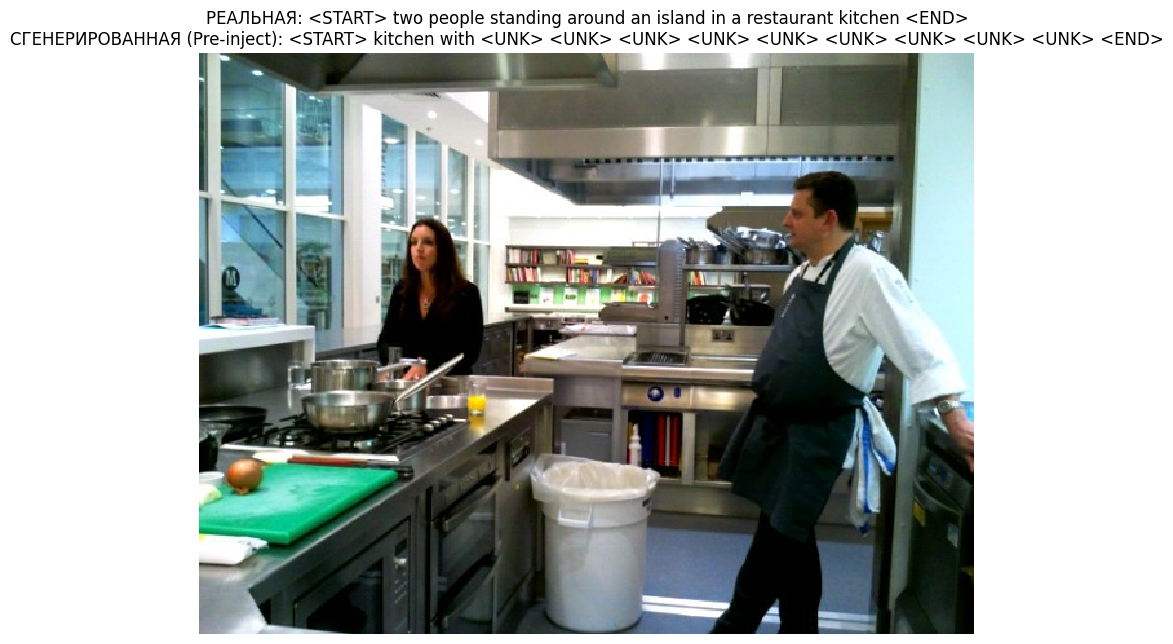

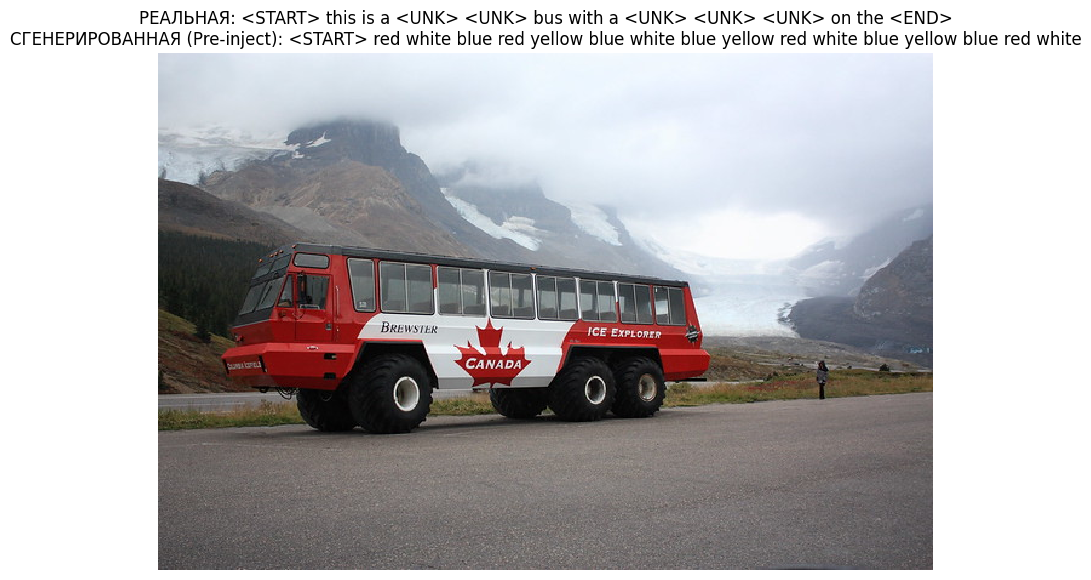

In [41]:
# Тестирования второй модели (Pre-inject)

def sample_preinject(model, features, max_len=16):
    model.eval()
    caption = []
    
    with torch.no_grad():
        img_embed = model.img_to_word_vec(features.to(device).unsqueeze(0))
        _, (h, c) = model.lstm(img_embed.unsqueeze(0))
        
        start_token_idx = full_data['word_to_idx']['<START>']
        word_idx = torch.tensor(start_token_idx).view(1, 1).to(device).long()
        caption.append(start_token_idx)

        # 3Генерация 
        for _ in range(max_len):
            word_embed = model.word_embedding(word_idx)
            lstm_out, (h, c) = model.lstm(word_embed, (h, c))
            scores = model.hidden_to_vocab(lstm_out.squeeze(0))
            _, next_word_idx = scores.max(1)
            caption.append(next_word_idx.item())
            if next_word_idx.item() == full_data['word_to_idx']['<END>']:
                break
            word_idx = next_word_idx.unsqueeze(0)
            
    return np.array(caption)

num_samples = 3
print("Генерируем подписи с помощью второй модели (Pre-inject):")
for i in range(num_samples):
    idx = np.random.choice(len(full_data['val_captions']))
    caption_nums = full_data['val_captions'][idx]
    url = full_data['val_urls'][full_data['val_image_idxs'][idx]]
    features_single = torch.from_numpy(full_data['val_features'][full_data['val_image_idxs'][idx]])

    generated_caption_nums = sample_preinject(preinject_model, features_single)
    
    real_caption_text = decode_captions(caption_nums, full_data['idx_to_word'])
    generated_caption_text = decode_captions(generated_caption_nums, full_data['idx_to_word'])
    
    img = image_from_url(url)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"РЕАЛЬНАЯ: {real_caption_text}\nСГЕНЕРИРОВАННАЯ (Pre-inject): {generated_caption_text}")
    plt.show()

In [42]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lizak\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [43]:
# Расчет метрики BLEU 

import nltk
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt') 

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

num_eval_samples = 500 

eval_indices = np.random.choice(len(full_data['val_captions']), num_eval_samples, replace=False)

def prepare_text_for_bleu(caption_nums, idx_to_word_list):
    """
    Декодирует подпись и удаляет специальные токены для BLEU-оценки.
    """
    decoded_words = []
    for idx in caption_nums:
        if 0 <= idx < len(idx_to_word_list):
            word = idx_to_word_list[idx] 
            if word not in ['<START>', '<END>', '<NULL>', '<UNK>']:
                decoded_words.append(word)
    return decoded_words

# Расчет BLEU для первой модели (Init-inject)
print("Расчет BLEU для Init-inject модели...")
bleu_scores_init_inject = {1: [], 2: [], 3: [], 4: []}
smooth = SmoothingFunction().method1 

for i in eval_indices:
    real_caption_nums = full_data['val_captions'][i]
    references = [prepare_text_for_bleu(real_caption_nums, full_data['idx_to_word'])]
    
    # Генерируем подпись
    features_single = torch.from_numpy(full_data['val_features'][full_data['val_image_idxs'][i]])
    generated_caption_nums = sample(final_model, features_single)
    candidate = prepare_text_for_bleu(generated_caption_nums, full_data['idx_to_word'])
    
    # Считаем BLEU для разных N-грамм
    if len(candidate) > 0: # Избегаем пустых генераций
        for n in range(1, 5):
            weights = tuple(1./n for _ in range(n))
            score = sentence_bleu(references, candidate, weights=weights, smoothing_function=smooth)
            bleu_scores_init_inject[n].append(score)

print("\n--- Результаты BLEU для Init-inject модели ---")
for n in range(1, 5):
    print(f"BLEU-{n}: {np.mean(bleu_scores_init_inject[n]):.4f}")

# Расчет BLEU для второй модели (Pre-inject)
print("\nРасчет BLEU для Pre-inject модели...")
bleu_scores_pre_inject = {1: [], 2: [], 3: [], 4: []}

for i in eval_indices:
    real_caption_nums = full_data['val_captions'][i]
    references = [prepare_text_for_bleu(real_caption_nums, full_data['idx_to_word'])]
    
    features_single = torch.from_numpy(full_data['val_features'][full_data['val_image_idxs'][i]])
    generated_caption_nums = sample_preinject(preinject_model, features_single)
    candidate = prepare_text_for_bleu(generated_caption_nums, full_data['idx_to_word'])
    
    if len(candidate) > 0:
        for n in range(1, 5):
            weights = tuple(1./n for _ in range(n))
            score = sentence_bleu(references, candidate, weights=weights, smoothing_function=smooth)
            bleu_scores_pre_inject[n].append(score)

print("\n--- Результаты BLEU для Pre-inject модели ---")
for n in range(1, 5):
    print(f"BLEU-{n}: {np.mean(bleu_scores_pre_inject[n]):.4f}")

Расчет BLEU для Init-inject модели...

--- Результаты BLEU для Init-inject модели ---
BLEU-1: 0.2901
BLEU-2: 0.1479
BLEU-3: 0.0893
BLEU-4: 0.0625

Расчет BLEU для Pre-inject модели...

--- Результаты BLEU для Pre-inject модели ---
BLEU-1: 0.1623
BLEU-2: 0.0425
BLEU-3: 0.0256
BLEU-4: 0.0219


# Выводы по лабораторной работе

В ходе данной лабораторной работы была реализована модель для генерации подписей к изображениям (Image Captioning) на основе архитектуры CNN+RNN.

### 1. Реализованные архитектуры
Были реализованы и сравнены две архитектуры для объединения признаков изображения и текстовых данных, описанные в статье "Where to put the Image in an Image Caption Generator":
1.  **(a) Init-inject:** Вектор признаков изображения используется для инициализации начального скрытого состояния LSTM-декодера.
2.  **(b) Pre-inject:** Вектор признаков изображения подается как самый первый элемент последовательности на вход LSTM.

### 2. Процесс обучения
Обе модели обучались в одинаковых условиях для честного сравнения: 4 эпохи на полном обучающем датасете COCO с использованием СPU. В процессе обучения отслеживалась функция потерь (Cross-Entropy Loss) на обучающей и валидационной выборках. Было экспериментально установлено, что обучение более 4-х эпох приводит к **переобучению** (росту `Val Loss`).

### 3. Сравнение моделей и результаты
Сравнение проводилось как визуально, так и с помощью стандартной метрики **BLEU**.

-   **Визуальная оценка:** Модель `Init-inject` генерировала более длинные, осмысленные и релевантные изображениям подписи. Модель `Pre-inject` часто генерировала лишь 2-3 слова и обрывалась на токенах `<UNK>`.
-   **Оценка BLEU:** Численные результаты полностью подтвердили визуальные наблюдения. Модель `Init-inject` показала значительно лучшие результаты по всем метрикам BLEU, превосходя вторую модель в 2-3 раза.

| Метрика | Init-inject | Pre-inject |
| :--- | :---: | :---: |
| **BLEU-1** | **0.2901** | 0.1623 |
| **BLEU-2** | **0.1479** | 0.0425 |
| **BLEU-3** | **0.0893** | 0.0256 |
| **BLEU-4** | **0.0625** | 0.0219 |

### Итоговое заключение
Экспериментально установлено, что для данной задачи архитектура **Init-inject** является значительно более эффективной. Она быстрее сходится (показывает меньший `Loss`) и генерирует более качественные и полные подписи, что подтверждается как визуальной оценкой, так и метрикой BLEU.